In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import random

from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
# observations = []
# actions  = []

# # ['smm', 'icm', 'icm_apt', 'disagreement', 'proto', 'diayn', 'aps', 'rnd']
# for ualgo in ['icm_apt']:
#     npz_files = os.listdir(f'datasets/point_mass_maze/{ualgo}/buffer/')
#     for file_name in tqdm(npz_files, desc=ualgo):
#         data = np.load(f'datasets/point_mass_maze/{ualgo}/buffer/{file_name}')
#         observations.append(data['observation'])
#         actions.append(data['action'])
    
# observations = torch.tensor(np.concatenate(observations))
# actions = torch.tensor(np.concatenate(actions))

## FRE:

In [113]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        state_emb = self.state_embed(states)        

        w_pre = self.encoder_transformer(state_emb, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [114]:
def get_training_data(batch_size, min_num_anchors, max_num_anchors, num_states):
    assert min_num_anchors <= max_num_anchors <= num_states
    # anchors_idx = torch.randint(0, observations.shape[0], (batch_size, num_anchors,))
    # other_idx = torch.randint(0, observations.shape[0], (batch_size, num_states - num_anchors,))
    # anchors = observations[anchors_idx]
    # non_anchors = observations[other_idx]
    
    anchors = torch.rand((batch_size, max_num_anchors, 2)) * 0.6 - 0.3
    non_anchors = torch.rand((batch_size, num_states - max_num_anchors, 2)) * 0.6 - 0.3
    
    # print(anchors.shape, non_anchors.shape)

    all_states = torch.concatenate((anchors, non_anchors), dim=1)
    all_states.shape

    rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float32)
    rewards[:, :max_num_anchors] = 1
    rewards[:, max_num_anchors:] = 0
    
    pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
    for i in range(batch_size):
        num_anchors = random.randint(min_num_anchors, max_num_anchors)
        anchors   [i, num_anchors:max_num_anchors] = 0
        all_states[i, num_anchors:max_num_anchors] = 0
        rewards   [i, num_anchors:max_num_anchors] = 0
        pad_mask  [i, :num_anchors] = False
        

    return (anchors, pad_mask), (all_states, rewards)


(anchors, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=256, 
    min_num_anchors=4,
    max_num_anchors=7,
    num_states=128)

In [115]:
# anchors.shape, pad_mask.shape

# embeddings = anchors
# padding_mask = pad_mask

# # Convert padding mask to a float tensor for computation
# valid_tokens = (~padding_mask).float()  # (B, T), converts True -> 0, False -> 1
# valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
# sum_embeddings = (embeddings * valid_tokens).sum(dim=1)  # Sum over sequence dimension
# mean_embeddings = sum_embeddings / valid_tokens.sum(dim=1)

In [181]:
fre_network = FRENetwork(obs_len=2).to(device)
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

steps = 100000

losses = []
pred_losses = []

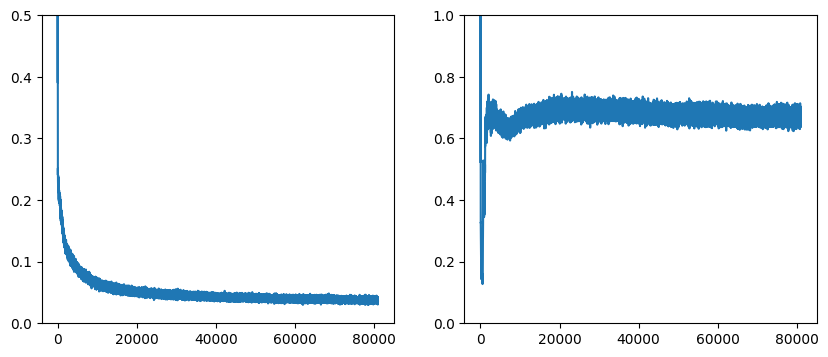

 82%|████████▏ | 81571/100000 [14:22<03:13, 95.22it/s]

In [182]:
min_num_anchors = 1
max_num_anchors = 10

for i in tqdm(range(steps)):
    
    (anchors, pad_mask), (all_states, rewards) = get_training_data(
        batch_size=256, 
        min_num_anchors=min_num_anchors, 
        max_num_anchors=max_num_anchors,
        num_states=16
    )
    anchors = anchors.to(device)
    pad_mask = pad_mask.to(device)
    all_states = all_states.to(device)
    rewards = rewards.to(device)
    
    w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, pad_mask=pad_mask)
    
    
    # Calculate the loss:
    
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    rewards_pred = fre_network.get_reward_pred(w, all_states)
    
    reward_pred_loss = ((rewards_pred - rewards)**2).mean()
    kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
    reward_kl_loss = reward_pred_loss + kl_loss * 0.01
    loss = reward_kl_loss
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    losses.append(loss.item())
    pred_losses.append(kl_loss.item())
    
    # break
    if i % 1000 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
        axs[0].plot(losses)
        axs[0].set_ylim([0, 0.5])
        
        axs[1].plot(pred_losses)
        axs[1].set_ylim([0, 1])
        
    
        plt.show()
        
        

In [174]:
# torch.save(fre_network.state_dict(), 'models/reward_generator.pth')
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))

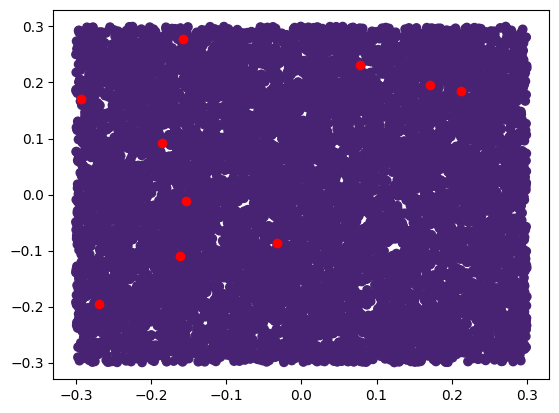

In [176]:
num_anchors = 10
min_num_anchors, max_num_anchors = num_anchors, num_anchors
(anchors, pad_mask), (all_states, rewards) = get_training_data(
    batch_size=1, 
    min_num_anchors=min_num_anchors, 
    max_num_anchors=max_num_anchors,
    num_states=10000
)
anchors = anchors.to(device)
all_states = all_states.to(device)
rewards = rewards.to(device)


w_mean, w_log_std = fre_network.get_transformer_encoding(anchors, None)   

# Calculate the loss:

w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
w = w_mean
rewards_pred = fre_network.get_reward_pred(w_mean, all_states)

reward_pred_loss = ((rewards_pred - rewards)**2).mean()
kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
reward_kl_loss = reward_pred_loss + kl_loss * 0.01
loss = reward_kl_loss

plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)
plt.scatter(anchors[0, :, 0].cpu(), anchors[0, :, 1].cpu(), c='red')

In [ ]:
torch.exp(w_log_std)

tensor([[0.1156, 0.1684, 0.0715, 0.1074, 0.0242, 0.1449, 0.1544, 0.1070, 0.1643,
         0.1523, 0.0156, 0.0462, 0.1770, 0.0627, 0.0284, 0.0315, 0.0560, 0.0481,
         0.1704, 0.1037, 0.1374, 0.1827, 0.0256, 0.1353, 0.1619, 0.1739, 0.0273,
         0.1674, 0.0163, 0.0346, 0.0394, 0.0964, 0.0334, 0.0103, 0.1967, 0.0854,
         0.0479, 0.0192, 0.1323, 0.0274, 0.1245, 0.1584, 0.0648, 0.0371, 0.1814,
         0.1522, 0.0233, 0.1784, 0.0560, 0.0877, 0.1532, 0.1415, 0.1247, 0.1181,
         0.1584, 0.0486, 0.0555, 0.1517, 0.0155, 0.0348, 0.1296, 0.1528, 0.1550,
         0.1790, 0.1610, 0.0409, 0.1361, 0.0223, 0.1311, 0.1810, 0.1551, 0.1922,
         0.1378, 0.1001, 0.0171, 0.1656, 0.1781, 0.0279, 0.1390, 0.0200, 0.1245,
         0.1610, 0.1528, 0.0107, 0.0185, 0.1536, 0.1067, 0.1798, 0.1756, 0.1185,
         0.0707, 0.1517, 0.1338, 0.1959, 0.0554, 0.0549, 0.0785, 0.0170, 0.0332,
         0.1368, 0.0657, 0.1782, 0.0147, 0.0327, 0.1940, 0.0949, 0.1329, 0.1754,
         0.0437, 0.1686, 0.1